In [1]:
import requests, pandas as pd
from requests.auth import HTTPBasicAuth
from dotenv import load_dotenv
import os

load_dotenv()  # Load from .env

reed_key = os.getenv("REED_API_KEY")

base = "https://www.reed.co.uk/api/1.0/search"
all_jobs = []

for skip in range(0, 1000, 100):  # Pages of 100 up to 1000
    params = {
        "keywords": "data analyst",
        "locationName": "United Kingdom",
        "resultsToTake": 100,
        "resultsToSkip": skip
    }
    resp = requests.get(base, auth=HTTPBasicAuth(reed_key, ""), params=params)
    data = resp.json().get('results', [])
    all_jobs.extend(data)

jobs_reed = pd.json_normalize(all_jobs)
jobs_reed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   jobId                1000 non-null   int64  
 1   employerId           1000 non-null   int64  
 2   employerName         1000 non-null   object 
 3   employerProfileId    0 non-null      object 
 4   employerProfileName  0 non-null      object 
 5   jobTitle             1000 non-null   object 
 6   locationName         1000 non-null   object 
 7   minimumSalary        836 non-null    float64
 8   maximumSalary        836 non-null    float64
 9   currency             836 non-null    object 
 10  expirationDate       1000 non-null   object 
 11  date                 1000 non-null   object 
 12  jobDescription       1000 non-null   object 
 13  applications         1000 non-null   int64  
 14  jobUrl               1000 non-null   object 
dtypes: float64(2), int64(3), object(10)
mem

In [2]:
# Save to CSV
jobs_reed.to_csv('data_analyst_jobs.csv', index=False)
print("Data saved to 'data_analyst_jobs.csv'")


Data saved to 'data_analyst_jobs.csv'


In [3]:
jobs_reed.isnull().sum()

jobId                     0
employerId                0
employerName              0
employerProfileId      1000
employerProfileName    1000
jobTitle                  0
locationName              0
minimumSalary           164
maximumSalary           164
currency                164
expirationDate            0
date                      0
jobDescription            0
applications              0
jobUrl                    0
dtype: int64

In [4]:
            # Dropping column which is completely missing like employerProfileId and employerProfileName
jobs_reed.drop(columns=["employerProfileId", "employerProfileName"], inplace=True)
# Filter rows with posting date from March 2025 onwards
jobs_reed['date'] = pd.to_datetime(jobs_reed['date'], format='%d/%m/%Y', errors='coerce')
jobs_reed = jobs_reed[jobs_reed['date'] >= '2025-03-01']

jobs_reed.head()


,jobId,employerId,employerName,jobTitle,locationName,minimumSalary,maximumSalary,currency,expirationDate,date,jobDescription,applications,jobUrl
0,55498827,675821,AJR Management Ltd,Data Analyst,DE130AT,27070.0,27070.0,GBP,09/09/2025,2025-07-29,Join a growing team in a dynamic environment! ...,162,https://www.reed.co.uk/jobs/data-analyst/55498827
1,55472028,422355,McCormick UK Limited,Data Analyst,Peterborough,NaN,NaN,None,04/09/2025,2025-07-24,"Data Analyst Peterborough, UK This role suppor...",87,https://www.reed.co.uk/jobs/data-analyst/55472028
2,55545639,401475,Mortgage Advice Bureau (MAB),Data Analyst,DE248QR,NaN,NaN,None,16/09/2025,2025-08-05,"Permanent, Full-time (37.5 hours, Monday to Fr...",41,https://www.reed.co.uk/jobs/data-analyst/55545639
3,54606079,510736,Sagacity,Data Analyst,EC1N2TD,NaN,NaN,None,12/09/2025,2025-03-07,Principal responsibilities will involve: Turn ...,3555,https://www.reed.co.uk/jobs/data-analyst/54606079
4,55420242,500373,QA,AI & Data Analyst Apprentice,SW1A1AA,16000.0,16000.0,GBP,26/08/2025,2025-07-15,"In today’s data-driven world, roles in data an...",83,https://www.reed.co.uk/jobs/ai-data-analyst-ap...


In [5]:
                # Filling missing values on minimumSalary,minimumSalary and currency

In [6]:
# Drop NaNs to avoid errors in calculations
min_salary = jobs_reed['minimumSalary']
max_salary = jobs_reed['maximumSalary']

# Fill missing values in 'minimumSalary' and 'maximumSalary' with the median salary
jobs_reed['minimumSalary'] = jobs_reed['minimumSalary'].fillna(jobs_reed['minimumSalary'].median())
jobs_reed['maximumSalary'] = jobs_reed['maximumSalary'].fillna(jobs_reed['maximumSalary'].median())


# Get the most frequent currency value
currency_mode = jobs_reed['currency'].mode().iloc[0]
# print(f"Most frequent currency: {currency_mode}")

# Fill missing values in 'currency' with the mode to maintain consistency in currency data
jobs_reed['currency'] = jobs_reed['currency'].fillna(currency_mode)

In [7]:
# Drop rows where both minimumSalary and maximumSalary are 0
jobs_reed = jobs_reed[~((jobs_reed['minimumSalary'] == 0) & (jobs_reed['maximumSalary'] == 0))]

# Drop rows where both minimumSalary or maximumSalary >150000
jobs_reed = jobs_reed[~((jobs_reed['minimumSalary'] > 150000)  | (jobs_reed['maximumSalary'] > 150000))]

# Drop rows where applications > 600
jobs_reed = jobs_reed[~((jobs_reed['applications'] > 600))]



# Checking
jobs_reed[(jobs_reed['minimumSalary'] == 0) | (jobs_reed['maximumSalary'] == 0)]

jobs_reed[(jobs_reed['minimumSalary'] > 150000) | (jobs_reed['maximumSalary'] > 150000)]

jobs_reed[(jobs_reed['applications'] > 600)]


,jobId,employerId,employerName,jobTitle,locationName,minimumSalary,maximumSalary,currency,expirationDate,date,jobDescription,applications,jobUrl


In [8]:
jobs_reed.describe()


,jobId,employerId,minimumSalary,maximumSalary,date,applications
count,9.800000e+02,980.000000,980.000000,980.000000,980,980.00000
mean,5.544899e+07,492995.457143,34102.554102,45616.803745,2025-07-20 08:03:25.714285824,49.44898
min,5.460720e+07,2763.000000,1.000000,12.600000,2025-03-07 00:00:00,0.00000
25%,5.540969e+07,402603.250000,30000.000000,40000.000000,2025-07-14 00:00:00,6.00000
50%,5.546460e+07,544251.500000,30000.000000,50000.000000,2025-07-23 00:00:00,25.50000
75%,5.550929e+07,582327.000000,40000.000000,50000.000000,2025-07-30 00:00:00,62.00000
max,5.555646e+07,690217.000000,100000.000000,130000.000000,2025-08-07 00:00:00,563.00000
std,9.319800e+04,145121.716489,15577.246300,18582.135339,NaN,71.11320


In [9]:
jobs_reed.info()


<class 'pandas.core.frame.DataFrame'>
Index: 980 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   jobId           980 non-null    int64         
 1   employerId      980 non-null    int64         
 2   employerName    980 non-null    object        
 3   jobTitle        980 non-null    object        
 4   locationName    980 non-null    object        
 5   minimumSalary   980 non-null    float64       
 6   maximumSalary   980 non-null    float64       
 7   currency        980 non-null    object        
 8   expirationDate  980 non-null    object        
 9   date            980 non-null    datetime64[ns]
 10  jobDescription  980 non-null    object        
 11  applications    980 non-null    int64         
 12  jobUrl          980 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(7)
memory usage: 107.2+ KB


In [10]:
# Convert 'date' column to datetime 
jobs_reed['date'] = pd.to_datetime(jobs_reed['date'], dayfirst=True)
jobs_reed['expirationDate'] = pd.to_datetime(jobs_reed['expirationDate'], dayfirst=True)


In [11]:
jobs_reed['date'] = pd.to_datetime(jobs_reed['date'])

# Calculate how many days old the job posting is
jobs_reed['jobAgeDays'] = (pd.Timestamp.today() - jobs_reed['date']).dt.days
jobs_reed

,jobId,employerId,employerName,jobTitle,locationName,minimumSalary,maximumSalary,currency,expirationDate,date,jobDescription,applications,jobUrl,jobAgeDays
0,55498827,675821,AJR Management Ltd,Data Analyst,DE130AT,27070.0,27070.0,GBP,2025-09-09,2025-07-29,Join a growing team in a dynamic environment! ...,162,https://www.reed.co.uk/jobs/data-analyst/55498827,9
1,55472028,422355,McCormick UK Limited,Data Analyst,Peterborough,30000.0,50000.0,GBP,2025-09-04,2025-07-24,"Data Analyst Peterborough, UK This role suppor...",87,https://www.reed.co.uk/jobs/data-analyst/55472028,14
2,55545639,401475,Mortgage Advice Bureau (MAB),Data Analyst,DE248QR,30000.0,50000.0,GBP,2025-09-16,2025-08-05,"Permanent, Full-time (37.5 hours, Monday to Fr...",41,https://www.reed.co.uk/jobs/data-analyst/55545639,2
4,55420242,500373,QA,AI & Data Analyst Apprentice,SW1A1AA,16000.0,16000.0,GBP,2025-08-26,2025-07-15,"In today’s data-driven world, roles in data an...",83,https://www.reed.co.uk/jobs/ai-data-analyst-ap...,23
5,55420229,500373,QA,AI & Data Analyst Apprentice,SL11XW,16000.0,16000.0,GBP,2025-08-26,2025-07-15,"In today’s data-driven world, roles in data an...",32,https://www.reed.co.uk/jobs/ai-data-analyst-ap...,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,55335675,524744,Hays Specialist Recruitment Limited,"Scrum Master / Business Analyst- Healthcare, D...",London,30000.0,50000.0,GBP,2025-08-13,2025-07-02,"Scrum Master - Healthcare, Data, Azure Market ...",200,https://www.reed.co.uk/jobs/scrum-master-busin...,36
996,55379260,464685,Lorien,Business Analyst,Edinburgh,400.0,450.0,GBP,2025-08-19,2025-07-08,BUSINESS ANALYST - INSIDE IR35 - 6 MONTHS One ...,157,https://www.reed.co.uk/jobs/business-analyst/5...,30
997,55523332,664120,Robert Half,Senior Finance Analyst,Bristol,60000.0,70000.0,GBP,2025-09-12,2025-08-01,Robert Half Finance &amp; Accounting are curre...,12,https://www.reed.co.uk/jobs/senior-finance-ana...,6
998,55352742,582710,BRELLIS RECRUITMENT LIMITED,Business Analyst,Leamington Spa,40000.0,50000.0,GBP,2025-08-15,2025-07-04,Business Analyst Salary 40k-50k per annum Priv...,203,https://www.reed.co.uk/jobs/business-analyst/5...,34


In [12]:

# Statistics for minimumSalary
print("Minimum Salary Stats:")
print(f"Min: {min_salary.min()}")
print(f"Max: {min_salary.max()}")
print(f"Mean: {min_salary.mean()}")
print(f"Mode: {min_salary.mode().values}")
print(f"Standard Deviation: {min_salary.std()}")
print()

# Statistics for maximumSalary
print("Maximum Salary Stats:")
print(f"Min: {max_salary.min()}")
print(f"Max: {max_salary.max()}")
print(f"Mean: {max_salary.mean()}")
print(f"Mode: {max_salary.mode().values}")
print(f"Standard Deviation: {max_salary.std()}")

Minimum Salary Stats:
Min: 0.0
Max: 100000.0
Mean: 34643.897243047155
Mode: [30000.]
Standard Deviation: 17166.55235791652

Maximum Salary Stats:
Min: 0.0
Max: 670000.0
Mean: 45132.367194679566
Mode: [50000.]
Standard Deviation: 29914.686824585955


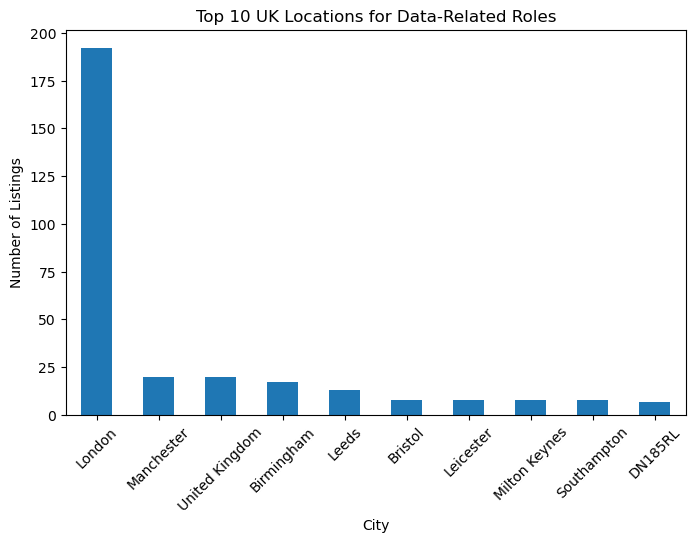

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
top_locations = jobs_reed['locationName'].value_counts().head(10)
top_titles    = jobs_reed['jobTitle'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_locations.plot(kind='bar')
plt.title('Top 10 UK Locations for Data-Related Roles')
plt.xlabel('City')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.show()


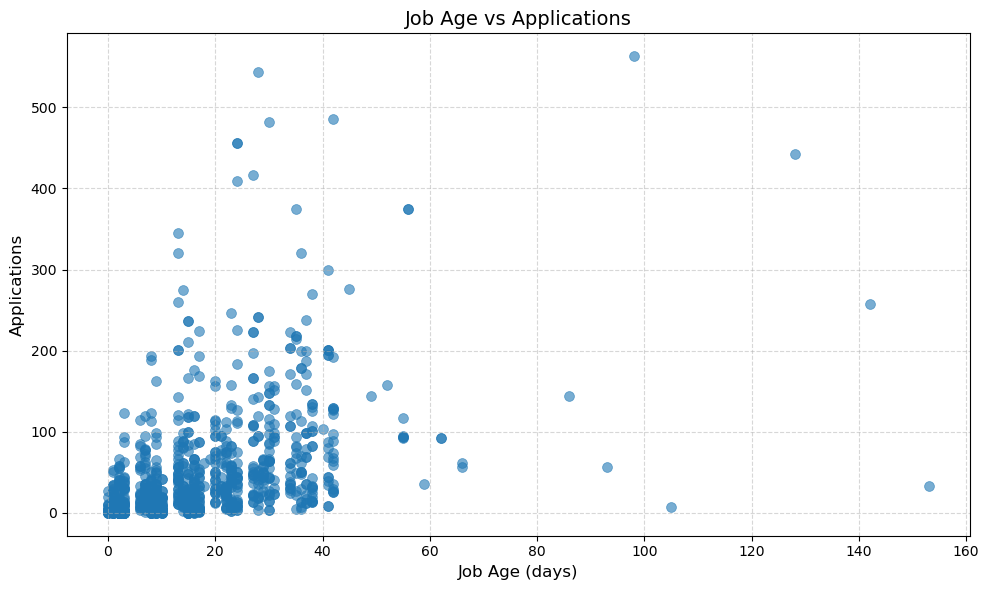

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 6))

# Scatter plot with adjusted appearance
sns.scatterplot(
    data=jobs_reed,
    x='jobAgeDays',
    y='applications',
    alpha=0.6,            # Transparency to reduce overlap clutter
    s=50,                 # Marker size
    edgecolor=None
)

# Title and labels
plt.title("Job Age vs Applications", fontsize=14)
plt.xlabel("Job Age (days)", fontsize=12)
plt.ylabel("Applications", fontsize=12)

# Format y-axis (Applications) as plain integers
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [15]:
max_applications = jobs_reed.loc[jobs_reed['applications'].idxmax()]
print("🔥 Job with the MOST applications:")
print(f"{max_applications['jobTitle']} at {max_applications['employerName']}")
print(f"Applications: {max_applications['applications']}")

min_applications = jobs_reed.loc[jobs_reed['applications'].idxmin()]
print("\n❄️ Job with the LEAST applications:")
print(f"{min_applications['jobTitle']} at {min_applications['employerName']}")
print(f"Applications: {min_applications['applications']}")

# jobs_reed[jobs_reed['applications'] == 0]

avg_applications = jobs_reed['applications'].mean()
print(f"\n📊 Average applications per job: {avg_applications:.2f}")


🔥 Job with the MOST applications:
IT Support Analyst at GroupNexus
Applications: 563

❄️ Job with the LEAST applications:
Leasing Decision Tree Analyst at Santander Consumer Finance
Applications: 0

📊 Average applications per job: 49.45


In [16]:
total_jobs = len(jobs_reed)
total_applications = jobs_reed['applications'].sum()

jobs_to_applications_ratio =  total_applications/  total_jobs
print(f"🔁 Applications-to-Jobs Ratio: {jobs_to_applications_ratio:.4f} ( application per jobs )")


🔁 Applications-to-Jobs Ratio: 49.4490 ( application per jobs )


In [17]:
older_than_30 = jobs_reed[jobs_reed['jobAgeDays'] > 30]
percent_older_than_30 = (len(older_than_30) / len(jobs_reed)) * 100

print(f"📌 Jobs older than 30 days: {len(older_than_30)}")
print(f"📊 Percentage of total: {percent_older_than_30:.2f}%")

posted_last_7_days = jobs_reed[jobs_reed['jobAgeDays'] <= 7]
percent_posted_last_7 = (len(posted_last_7_days) / len(jobs_reed)) * 100

print(f"📌 Jobs posted in last 7 days: {len(posted_last_7_days)}")
print(f"📊 Percentage of total: {percent_posted_last_7:.2f}%")


📌 Jobs older than 30 days: 155
📊 Percentage of total: 15.82%
📌 Jobs posted in last 7 days: 240
📊 Percentage of total: 24.49%


In [18]:
remote_jobs = jobs_reed[
    jobs_reed['jobTitle'].str.contains("remote", case=False, na=False) |
    jobs_reed['jobDescription'].str.contains("remote", case=False, na=False) |
    jobs_reed['locationName'].str.contains("remote", case=False, na=False)
]

hybrid_jobs = jobs_reed[
    jobs_reed['jobTitle'].str.contains("hybrid", case=False, na=False) |
    jobs_reed['jobDescription'].str.contains("hybrid", case=False, na=False) |
    jobs_reed['locationName'].str.contains("hybrid", case=False, na=False)
]

percent_remote = (len(remote_jobs) / len(jobs_reed)) * 100
percent_hybrid = (len(hybrid_jobs) / len(jobs_reed)) * 100

print(f"🏠 Remote jobs: {len(remote_jobs)} ({percent_remote:.2f}%)")
print(f"🏢 Hybrid jobs: {len(hybrid_jobs)} ({percent_hybrid:.2f}%)")


🏠 Remote jobs: 52 (5.31%)
🏢 Hybrid jobs: 246 (25.10%)


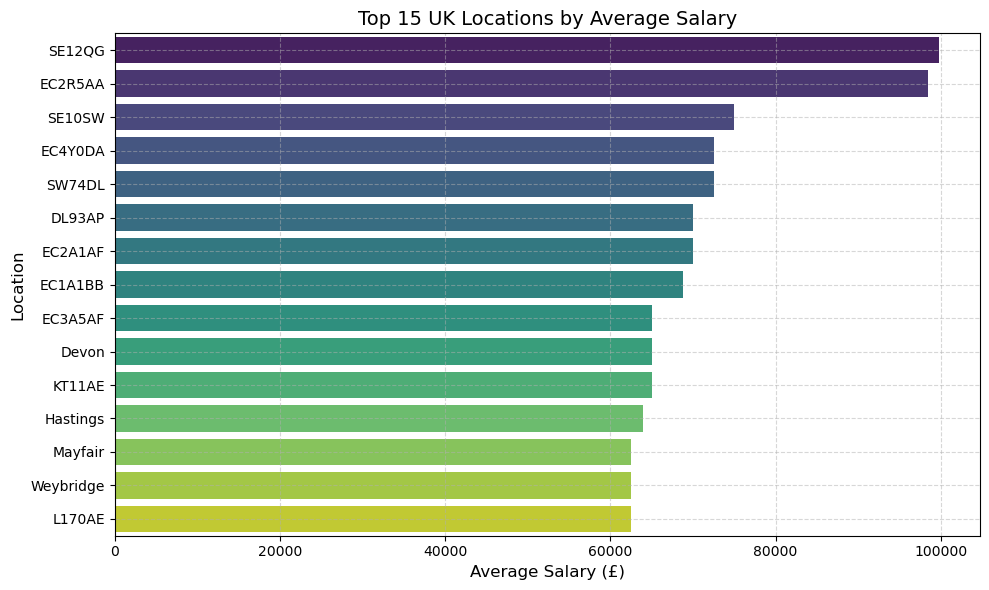

,locationName,salaryAvg
0,SE12QG,99750.0
1,EC2R5AA,98500.0
2,SE10SW,75000.0
3,EC4Y0DA,72500.0
4,SW74DL,72500.0
5,DL93AP,70000.0
6,EC2A1AF,70000.0
7,EC1A1BB,68750.0
8,EC3A5AF,65000.0
9,Devon,65000.0


In [19]:

import matplotlib.pyplot as plt
import seaborn as sns

jobs_reed['salaryAvg'] = (jobs_reed['minimumSalary'] + jobs_reed['maximumSalary']) / 2

top_locations_salary = (
    jobs_reed.groupby('locationName')['salaryAvg']
    .mean()
    .sort_values(ascending=False)
    .head(15)  # Top 15 locations
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_locations_salary,
    x='salaryAvg',
    y='locationName',
    palette='viridis'
)

# Titles and labels
plt.title('Top 15 UK Locations by Average Salary', fontsize=14)
plt.xlabel('Average Salary (£)', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

top_locations_salary.head(15)

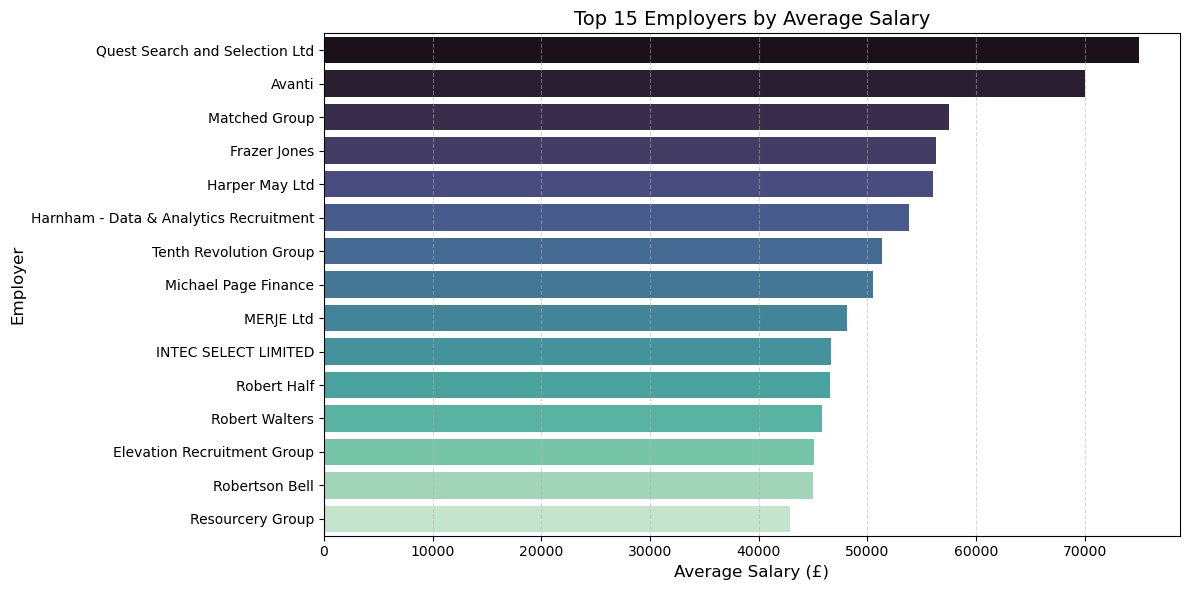

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Ensure salaryAvg is calculated
jobs_reed['salaryAvg'] = (jobs_reed['minimumSalary'] + jobs_reed['maximumSalary']) / 2

# Step 2: Group by employer
employer_salary = (
    jobs_reed.groupby('employerName')
    .agg(jobCount=('jobId', 'count'), avgSalary=('salaryAvg', 'mean'))
    .sort_values('avgSalary', ascending=False)
)

# Step 3: Filter employers with at least 3 listings to avoid noise
employer_salary_filtered = employer_salary[employer_salary['jobCount'] >= 3]

# Step 4: Plot top 15
plt.figure(figsize=(12, 6))
sns.barplot(
    data=employer_salary_filtered.head(15),
    x='avgSalary',
    y=employer_salary_filtered.head(15).index,
    palette='mako'
)

plt.title("Top 15 Employers by Average Salary", fontsize=14)
plt.xlabel("Average Salary (£)", fontsize=12)
plt.ylabel("Employer", fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


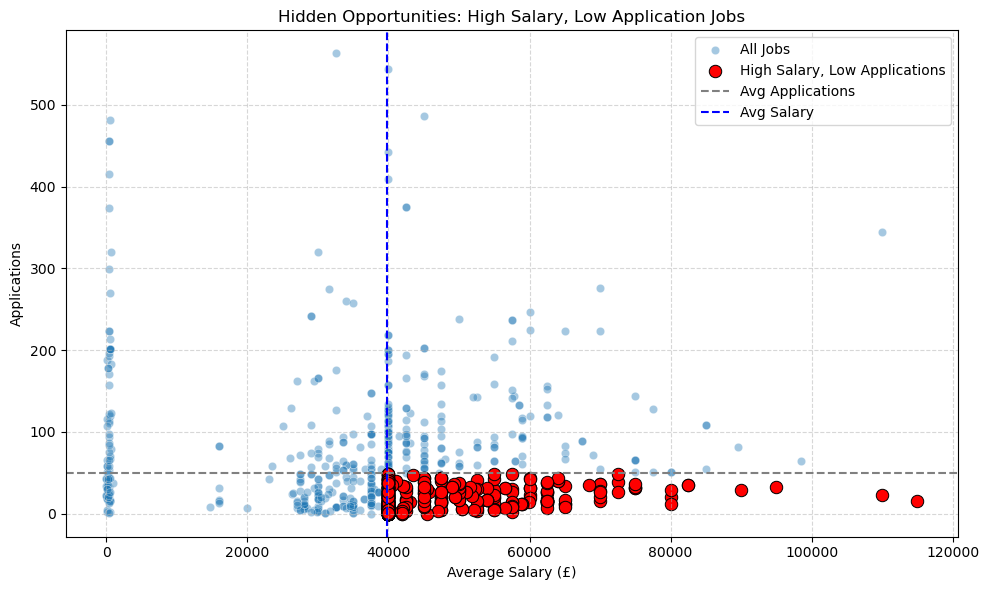

,jobTitle,employerName,locationName,salaryAvg,applications
912,Senior Financial Analyst,Robert Walters,London,115000.0,15
861,Senior Quantitative Analyst,Spectrum IT Recruitment,London,110000.0,23
646,Lead Data Scientist,Harnham - Data & Analytics Recruitment,Manchester,95000.0,33
711,Lead Product Analyst,Harnham - Data & Analytics Recruitment,London,90000.0,29
551,Finance Analyst,Halliday Marx,London,82500.0,35
631,Finance Analyst,Halliday Marx,London,82500.0,35
897,FP & A Analyst,Robert Half,Leeds,80000.0,20
321,Senior Data Enablement Analyst,Method Resourcing,London,80000.0,12
880,Senior Product Analyst,Harnham - Data & Analytics Recruitment,London,80000.0,29
587,Reinsurance Data Specialist,IPS Group,London,75000.0,31


In [21]:
# Step 1: Ensure salaryAvg is available
jobs_reed['salaryAvg'] = (jobs_reed['minimumSalary'] + jobs_reed['maximumSalary']) / 2

# Step 2: Get overall means
mean_salary = jobs_reed['salaryAvg'].mean()
mean_applications = jobs_reed['applications'].mean()

# Step 3: Filter hidden opportunities
hidden_opportunities = jobs_reed[
    (jobs_reed['salaryAvg'] > mean_salary) &
    (jobs_reed['applications'] < mean_applications)
]

# Step 4: Sort by highest salary
hidden_opportunities_sorted = hidden_opportunities.sort_values(by='salaryAvg', ascending=False)

# Display top 10


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=jobs_reed,
    x='salaryAvg',
    y='applications',
    alpha=0.4,
    label='All Jobs'
)

# Highlight hidden opportunities
sns.scatterplot(
    data=hidden_opportunities_sorted,
    x='salaryAvg',
    y='applications',
    color='red',
    label='High Salary, Low Applications',
    s=80,
    edgecolor='black'
)

plt.axhline(mean_applications, linestyle='--', color='gray', label='Avg Applications')
plt.axvline(mean_salary, linestyle='--', color='blue', label='Avg Salary')

plt.title('Hidden Opportunities: High Salary, Low Application Jobs')
plt.xlabel('Average Salary (£)')
plt.ylabel('Applications')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

hidden_opportunities_sorted[['jobTitle', 'employerName', 'locationName', 'salaryAvg', 'applications']].head(10)

/home/obsidian/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


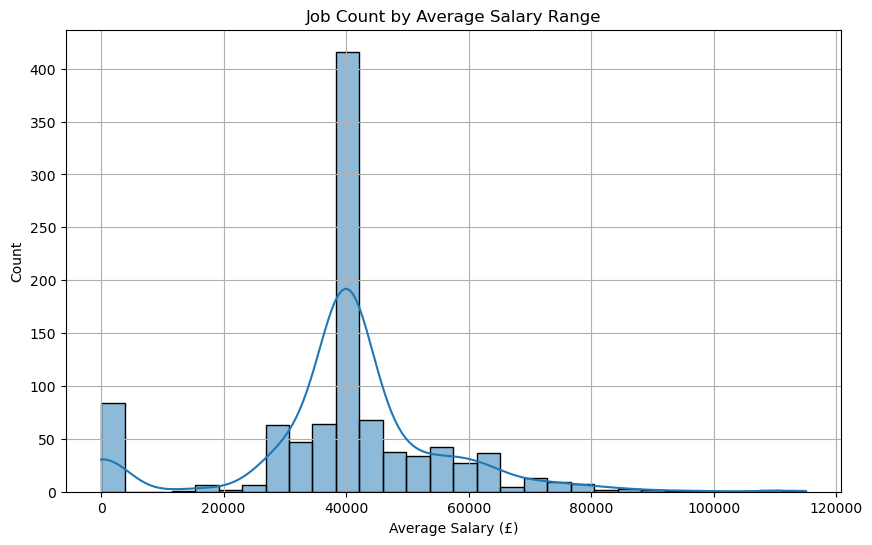

In [22]:
# filtered_jobs = jobs_reed[jobs_reed['salaryAvg'] ]

plt.figure(figsize=(10, 6))
sns.histplot(jobs_reed['salaryAvg'], kde=True, bins=30)
plt.title("Job Count by Average Salary Range")
plt.xlabel('Average Salary (£)')
plt.grid(True)
plt.show()

# Filter out extreme salary outliers (>100k)

In [23]:
# Count how many jobs each company is offering
top_employers = jobs_reed['employerName'].value_counts()

# View the top 10 companies
print(top_employers.head(20))


employerName
ITOL Recruit                              208
Harnham - Data & Analytics Recruitment     71
Reed                                       34
Robert Half                                29
Tenth Revolution Group                     24
Hays Specialist Recruitment Limited        23
Robert Walters                             17
Newto Training                             16
Michael Page Finance                       15
Adecco                                     11
QA                                         10
Sanderson                                  10
Oscar Technology                            9
Mitchell Adam                               9
The Portfolio Group                         8
Cedar                                       7
Harper May Ltd                              7
Interquest                                  6
Lorien                                      6
Harrison Holgate                            6
Name: count, dtype: int64


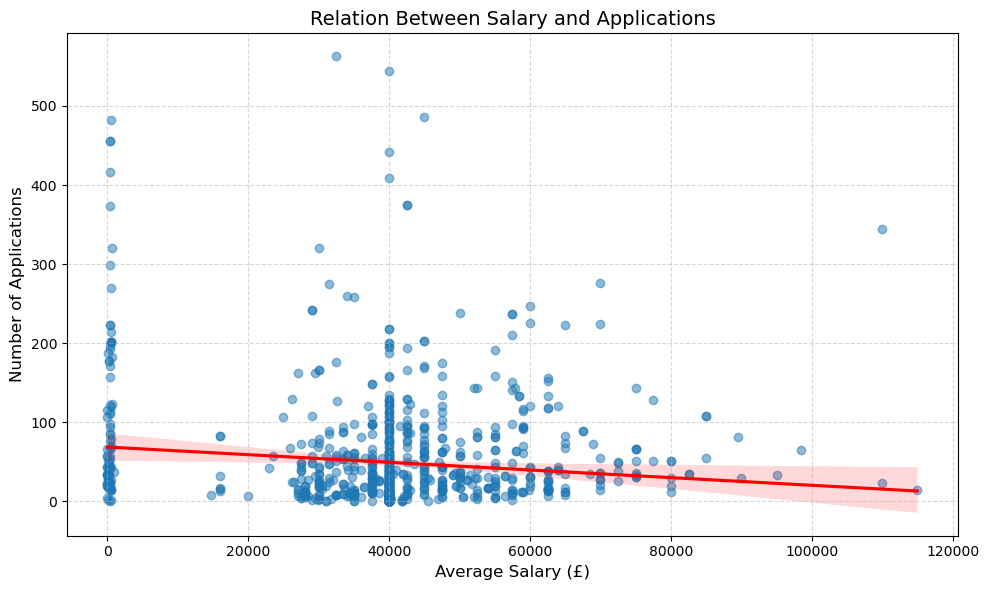

Pearson Correlation Coefficient: -0.113 (p-value: 0.0004)


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Step 1: Ensure salaryAvg is calculated
jobs_reed['salaryAvg'] = (jobs_reed['minimumSalary'] + jobs_reed['maximumSalary']) / 2

# Step 2: Scatterplot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(
    data=jobs_reed,
    x='salaryAvg',
    y='applications',
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'},
)

plt.title("Relation Between Salary and Applications", fontsize=14)
plt.xlabel("Average Salary (£)", fontsize=12)
plt.ylabel("Number of Applications", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Step 3: Pearson correlation coefficient
corr, p_value = pearsonr(jobs_reed['salaryAvg'], jobs_reed['applications'])
print(f"Pearson Correlation Coefficient: {corr:.3f} (p-value: {p_value:.4f})")


/home/obsidian/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


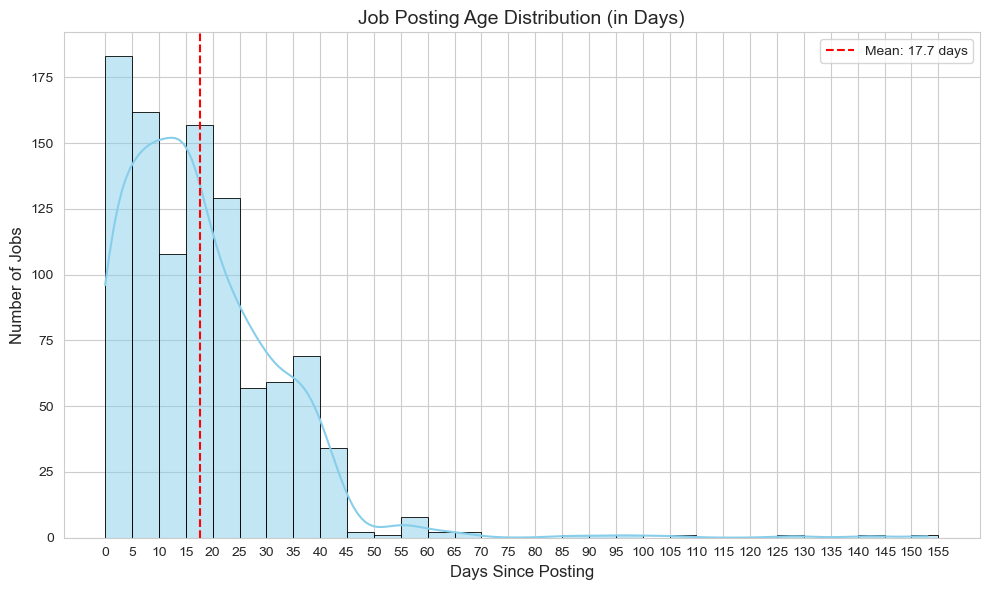

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure job age is calculated
jobs_reed['date'] = pd.to_datetime(jobs_reed['date'], errors='coerce')
jobs_reed['jobAgeDays'] = (pd.Timestamp.today() - jobs_reed['date']).dt.days

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Plot with smaller bin size
sns.histplot(
    jobs_reed['jobAgeDays'],
    bins=range(0, jobs_reed['jobAgeDays'].max() + 5, 5),  # bin every 5 days
    kde=True,
    color='skyblue',
    edgecolor='black',
    linewidth=0.6
)

# Add mean line
mean_age = jobs_reed['jobAgeDays'].mean()
plt.axvline(mean_age, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_age:.1f} days')

# Set ticks every 5 days
plt.xticks(np.arange(0, jobs_reed['jobAgeDays'].max() + 5, 5))

# Titles and labels
plt.title('Job Posting Age Distribution (in Days)', fontsize=14)
plt.xlabel('Days Since Posting', fontsize=12)
plt.ylabel('Number of Jobs', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
correlation_matrix = jobs_reed[['applications', 'salaryAvg', 'jobAgeDays']].corr()
print("📈 Correlation Matrix:\n", correlation_matrix)

📈 Correlation Matrix:
               applications  salaryAvg  jobAgeDays
applications      1.000000  -0.113402    0.452724
salaryAvg        -0.113402   1.000000    0.026943
jobAgeDays        0.452724   0.026943    1.000000
